In [ ]:
import pandas as pd

df = pd.read_csv("/content/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#Basic Level

In [ ]:
#How many rows and columns are in the dataset?
df.shape

(7043, 21)

In [ ]:
#What are the data types of each column?
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
#How many missing values are there in each column?
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
#How many unique customers are present?
df["customerID"].nunique()

7043

In [ ]:
#What is the overall churn rate?
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


#Intermediate Level

In [ ]:
#Gender-wise customer count
df["gender"].value_counts()

,count
gender,
Male,3555
Female,3488


In [ ]:
#Contract type distribution
df["Contract"].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


In [ ]:
#Average monthly charges
df["MonthlyCharges"].mean()

np.float64(64.76169246059918)

In [ ]:
#Churn rate by gender
df.groupby("gender")["Churn"].value_counts(normalize=True).unstack() * 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [ ]:
#Churn rate by contract type
df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack() * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


#Advanced Level

In [ ]:
#Average tenure of churned vs retained customers
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


In [ ]:
#Monthly charges of churned customers
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


In [ ]:
#Internet service vs churn
df.groupby("InternetService")["Churn"].value_counts(normalize=True).unstack() * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [ ]:
#Payment method with highest churn
df.groupby("PaymentMethod")["Churn"].value_counts(normalize=True).unstack() * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [ ]:
#Senior citizen churn analysis
df.groupby("SeniorCitizen")["Churn"].value_counts(normalize=True).unstack() * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


#Advance Level(deeper)

In [ ]:
#Top high-risk customer segment
high_risk = df[
    (df["Contract"] == "Month-to-month") &
    (df["TechSupport"] == "No") &
    (df["MonthlyCharges"] > 70)
]

high_risk.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes
19,4183-MYFRB,Female,0,No,No,21,Yes,No,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,90.05,1862.9,No


In [ ]:
#Revenue loss due to churn
df[df["Churn"] == "Yes"]["MonthlyCharges"].sum()

np.float64(139130.85)

In [ ]:
#Lifetime value by churn
df["LifetimeValue"] = df["tenure"] * df["MonthlyCharges"]
df.groupby("Churn")["LifetimeValue"].mean()

,LifetimeValue
Churn,
No,2549.770883
Yes,1531.608828


In [ ]:
#Correlation of numeric variables
df.select_dtypes(include=["int64", "float64"]).corr()

,SeniorCitizen,tenure,MonthlyCharges,LifetimeValue
SeniorCitizen,1.000000,0.016567,0.220173,0.103261
tenure,0.016567,1.000000,0.247900,0.826568
MonthlyCharges,0.220173,0.247900,1.000000,0.651566
LifetimeValue,0.103261,0.826568,0.651566,1.000000


In [ ]:
#Build churn prediction dataset
model_df = pd.get_dummies(df.drop("customerID", axis=1), drop_first=True)
model_df.head()

,SeniorCitizen,tenure,MonthlyCharges,LifetimeValue,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,1936.30,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,107.70,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0,45,42.30,1903.50,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,141.40,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
import matplotlib.pyplot as plt


<Axes: xlabel='Churn'>

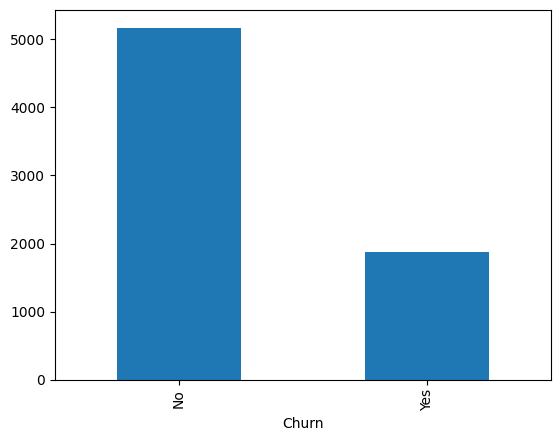

In [ ]:
#Churn count plot
df["Churn"].value_counts().plot(kind="bar")

<Axes: >

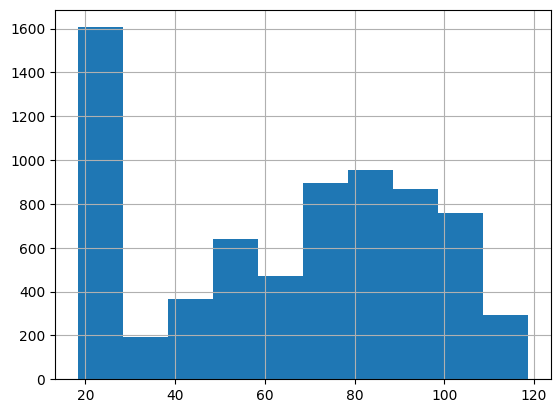

In [ ]:
#Monthly charges histogram
df["MonthlyCharges"].hist()

In [ ]:
# Example cleaning
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df = df.dropna()

# Export
df.to_csv("cleaned_telco_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("c.csv")